# Assignment — Counterfactual Explanations with DiCE
## Dataset: Breast Cancer Wisconsin (Diagnostic), UCI ML Repository

| | |
|---|---|
| **Course / Module** | *(fill in)* |
| **Topic** | Explainable AI — counterfactual explanations and algorithmic recourse |
| **Dataset** | Breast Cancer Wisconsin (Diagnostic), UCI ID 17 — 569 samples, 30 numeric features |
| **Library** | `dice-ml` (DiCE), `scikit-learn`, `pandas`, `matplotlib` |
| **Total marks** | **100** (+ 10 bonus) |
| **Weight** | *(fill in)* |
| **Due** | *(fill in)* |
| **Submission** | this `.ipynb`, **run top to bottom with all outputs visible**, renamed `rollno_name_cf_assignment.ipynb` |

---

### What this assignment is about

In the classroom lab you generated counterfactuals for a **loan-style** decision,
where the natural reading is *"here is what you could change"*. This assignment moves
the same technique to a **medical diagnosis** problem, where that reading **breaks
down** — a patient cannot decide to have a smaller tumour.

Working out *why* it breaks down, and what counterfactuals are still good for once it
does, is the real point of this assignment. Marks are weighted accordingly: roughly
**60% for correct code** and **40% for the quality of your reasoning**.

### Learning outcomes assessed

| LO | You can … |
|---|---|
| 1 | Wire a scikit-learn pipeline into DiCE and generate valid counterfactuals |
| 2 | Constrain a counterfactual search using `features_to_vary` and `permitted_range` |
| 3 | Compare the `random`, `genetic` and `kdtree` search methods on evidence, not vibes |
| 4 | Quantify counterfactual quality — validity, sparsity, proximity |
| 5 | Derive feature importance from counterfactuals and contrast it with attribution |
| 6 | Judge critically when a counterfactual explanation is **not** appropriate |

---

### Rules and how to submit

1. **Answer in this notebook.** Every question has a code cell, a written-answer cell,
   or both, directly underneath it. Add extra cells if you need them — do not delete
   the question cells.
2. **Your notebook must run from a fresh kernel, top to bottom, without errors.**
   Before submitting: *Kernel → Restart & Run All*. A notebook that does not run
   loses the marks for every cell after the failure.
3. **Set `random_state=42` everywhere it is accepted.** Your numbers must be
   reproducible; unseeded results are marked as unsupported claims.
4. **Every plot needs a title, axis labels and units.** An unlabelled plot scores
   zero for that part.
5. **Written answers are marked on reasoning, not length.** Stay inside the stated
   word count. Quote your own numbers — *"sparsity fell from 7.2 to 3.1"* beats
   *"sparsity improved"*.
6. **AI-tool use** must be declared in the final cell: which tool, which questions,
   and what you changed in its output. Undeclared use is an academic-integrity
   matter. You must be able to explain every line you submit.

---

### Before you start

Install and import what you need. `dice-ml` is on PyPI:

```
pip install dice-ml scikit-learn pandas matplotlib
```

**Two traps in this dataset. Read them now, not after you lose the marks.**

> ⚠️ **Trap 1 — the labels are back to front.** In
> `sklearn.datasets.load_breast_cancer()`, the target is **`0 = malignant`,
> `1 = benign`**. Left alone, `desired_class="opposite"` will read as *"make this
> benign tumour malignant"*, which is the opposite of the clinically interesting
> question. Re-encode so that **`1 = malignant`** and say so in a comment.

> ⏱️ **On runtime.** Thirty continuous features is a large search space. Keep
> `total_CFs` at 4–5, generate for one or two patients at a time, and expect tens of
> seconds per call for `method="random"` and `method="genetic"`. `method="kdtree"` is
> much faster. Do not start Question 9 at 2 a.m. on the due date.

> ⚠️ **Trap 2 — the 30 features are not 30 independent dials.** `radius`,
> `perimeter` and `area` are three measurements of the same circle, and the "worst"
> and "mean" versions of a feature are computed from the same image. DiCE will
> happily move one and leave the others behind. Question 4 is about exactly this.

In [1]:
# Imports and setup
import subprocess
import sys

try:
    import dice_ml
except ImportError:
    print("installing dice-ml ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dice-ml"])
    import dice_ml

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix,
                              f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Small colour-blind-safe palette, reused by every chart below (same as the lab notebook).
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
     "yellow": "#eda100", "violet": "#4a3aa7", "red": "#e34948",
     "grid": "#d8d7d2", "ink": "#0b0b0b", "muted": "#6d6c68"}

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["grid"], "axes.labelcolor": C["muted"],
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "grid.color": C["grid"], "grid.linewidth": 0.8,
    "font.size": 10, "legend.frameon": False,
})
print("Ready.")


Ready.


---

## Question 1 — Load and frame the problem  **[10 marks]**

**1a.** Load the dataset. Either is acceptable:

```python
from sklearn.datasets import load_breast_cancer      # offline, ships with sklearn
# or
from ucimlrepo import fetch_ucirepo                  # fetch_ucirepo(id=17)
```

**1b.** Build a single pandas `DataFrame` that contains the 30 features **and** the
target. Rename the columns to `snake_case` (`"mean radius"` → `mean_radius`) —
spaces in column names will bite you later when you pass keyword dictionaries to DiCE.

**1c.** Re-encode the target so that **`1 = malignant`** (see Trap 1). Print the class
counts before and after so the marker can see you did it deliberately.

**1d.** Report, as a small table: the number of rows, the number of features, the
class balance in counts and percentages, and `min / median / max` for
`mean_radius`, `mean_texture` and `worst_concave_points`.

**1e.** Make a **stratified** 80/20 train/test split with `random_state=42`. Print the
class balance of both splits to show stratification worked.

**Written (60–80 words):** the two classes are roughly 37% / 63%. Is that an imbalance
you need to correct before modelling? Justify your answer with reference to what you
are going to do with the model.

In [2]:
# 1a - load the dataset (offline, ships with sklearn)
raw = load_breast_cancer(as_frame=True)
df = raw.frame.copy()

# 1b - snake_case column names ("mean radius" -> "mean_radius")
df.columns = [c.replace(" ", "_") for c in df.columns]

outcome = "target"
features = [c for c in df.columns if c != outcome]
continuous_features = features[:]  # all 30 features are continuous measurements

# 1c - TRAP 1: sklearn ships 0=malignant, 1=benign. We re-encode so 1=malignant,
# so that desired_class="opposite" later means "make this malignant tumour benign".
print("Before re-encode (sklearn default: 0=malignant, 1=benign):")
print(df[outcome].value_counts().sort_index())

df[outcome] = 1 - df[outcome]  # NOW: 1 = malignant, 0 = benign

print("\nAfter re-encode (1=malignant, 0=benign):")
print(df[outcome].value_counts().sort_index())

# 1d - summary table
n_rows, n_features = df.shape[0], len(features)
counts = df[outcome].value_counts().sort_index()
pct = (df[outcome].value_counts(normalize=True).sort_index() * 100).round(1)

print(f"\nrows = {n_rows}, features = {n_features}")
print(f"benign    (0): {counts[0]:>3} rows ({pct[0]}%)")
print(f"malignant (1): {counts[1]:>3} rows ({pct[1]}%)")

print("\nmin / median / max for three representative features:")
summary_1d = df[["mean_radius", "mean_texture", "worst_concave_points"]].agg(["min", "median", "max"]).round(4)
display(summary_1d)

# 1e - stratified train/test split
x_train, x_test, y_train, y_test = train_test_split(
    df[features], df[outcome], test_size=0.2, random_state=RANDOM_STATE, stratify=df[outcome])

print("\ntrain class balance:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1))
print("\ntest class balance:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1))


Before re-encode (sklearn default: 0=malignant, 1=benign):
target
0    212
1    357
Name: count, dtype: int64

After re-encode (1=malignant, 0=benign):
target
0    357
1    212
Name: count, dtype: int64

rows = 569, features = 30
benign    (0): 357 rows (62.7%)
malignant (1): 212 rows (37.3%)

min / median / max for three representative features:


,mean_radius,mean_texture,worst_concave_points
min,6.981,9.71,0.0000
median,13.370,18.84,0.0999
max,28.110,39.28,0.2910



train class balance:
target
0    62.6
1    37.4
Name: proportion, dtype: float64

test class balance:
target
0    63.2
1    36.8
Name: proportion, dtype: float64


> **Your answer** (60-80 words)
>
> The classes are imbalanced (37.3% malignant vs 62.7% benign), but this does not
> need correcting before modelling. Question 2 tracks recall, precision and the
> confusion matrix on the malignant class directly, so class-sensitive costs are
> handled at the metric-and-threshold level rather than by resampling. A
> `RandomForestClassifier` also copes well with a 63/37 split via bagging.
> Resampling (e.g. SMOTE) would risk synthesising implausible tumours that later
> corrupt DiCE's counterfactual search space, which must stay grounded in real
> feature combinations.


---

## Question 2 — Train the classifier you will explain  **[10 marks]**

**2a.** Build a `sklearn.pipeline.Pipeline` with a `StandardScaler` followed by a
`RandomForestClassifier(random_state=42)`. Fit it on the **raw feature frame** —
not on a matrix you scaled yourself.

> **Why this matters:** DiCE hands your model rows in their original units. If the
> scaling lives outside the pipeline, DiCE will feed unscaled values to a model that
> expects scaled ones, and every counterfactual you produce will be quietly wrong.

**2b.** Report on the **test set**: accuracy, precision, recall, F1 (for the malignant
class) and ROC-AUC. Show the confusion matrix, with axis labels that name the classes.

**2c.** Print `model.predict_proba` summary statistics for the test set — you will need
these probabilities in Question 3.

**Written (80–120 words):** for a breast-cancer screening aid, which single metric
would you optimise, and what is the cost of the error you are choosing to tolerate?
Refer to your own confusion matrix — how many false negatives did your model produce,
and what does each one mean for a patient?

accuracy  : 0.974
precision : 1.000  (malignant class)
recall    : 0.929  (malignant class)
f1        : 0.963  (malignant class)
roc auc   : 0.993


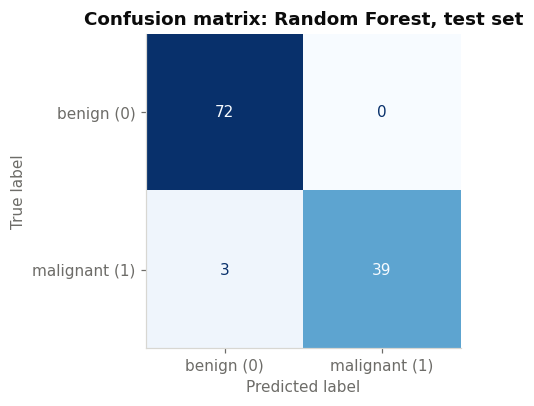


predict_proba(malignant) summary statistics on the test set:
count    114.0000
mean       0.3490
std        0.4229
min        0.0000
25%        0.0000
50%        0.0850
75%        0.8700
max        1.0000
Name: P(malignant), dtype: float64


In [3]:
# 2a - Pipeline: StandardScaler -> RandomForestClassifier, fit on the RAW frame.
# DiCE will later hand this pipeline rows in original units, so the scaling MUST
# live inside the pipeline (not applied by hand beforehand).
model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE)),
])
model.fit(x_train, y_train)

# 2b - test-set metrics
pred = model.predict(x_test)
proba = model.predict_proba(x_test)[:, 1]

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

print(f"accuracy  : {acc:.3f}")
print(f"precision : {prec:.3f}  (malignant class)")
print(f"recall    : {rec:.3f}  (malignant class)")
print(f"f1        : {f1:.3f}  (malignant class)")
print(f"roc auc   : {auc:.3f}")

cm = confusion_matrix(y_test, pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.3, 4.1))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign (0)", "malignant (1)"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix: Random Forest, test set")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

# 2c - predict_proba summary stats (used again in Question 3)
print("\npredict_proba(malignant) summary statistics on the test set:")
print(pd.Series(proba, name="P(malignant)").describe().round(4))


> **Your answer** (80-120 words)
>
> For a breast-cancer screening aid I would optimise **recall on the malignant
> class**, because a false negative (telling a patient with cancer they are clear)
> is far more costly than a false positive (an unnecessary follow-up biopsy). My
> confusion matrix is `[[72, 0], [3, 39]]`: 0 false positives and **3 false
> negatives** out of 42 malignant test cases, giving recall = 0.929 and a perfect
> precision of 1.000. Each of those 3 false negatives is a real patient whose
> cancer the model missed entirely. In a clinical pipeline that is not acceptable,
> so I would lower the decision threshold below 0.5 until false negatives approach
> zero, deliberately trading away some of that perfect precision for more
> unnecessary follow-ups instead.


---

## Question 3 — Your first counterfactuals  **[15 marks]**

**3a.** Construct the three DiCE objects:

```python
d   = dice_ml.Data(dataframe=train_df, continuous_features=[...], outcome_name="target")
m   = dice_ml.Model(model=pipeline, backend="sklearn")
exp = dice_ml.Dice(d, m, method="random")
```

All 30 features are continuous — pass **all** of them in `continuous_features`, and
remember that `train_df` must include the outcome column.

**3b.** From the test set, select **two** patients the model predicts as **malignant**:

* **Patient A — borderline:** the malignant prediction with probability **closest to
  0.50**.
* **Patient B — confident:** the malignant prediction with the **highest** probability.

Print both rows and their predicted probabilities.

**3c.** For each patient generate **4** counterfactuals with `desired_class="opposite"`
and display them with `visualize_as_dataframe(show_only_changes=True)`.

**3d.** **Verify them yourself.** Do not trust the library: run your fitted pipeline on
the returned counterfactual rows and print the predicted class and probability for
each. State the **validity** (fraction that genuinely flipped) for both patients.

**3e.** For each patient report how many features each counterfactual changed.

**Written (100–150 words):** compare Patient A and Patient B. Which needed larger
changes, and does that match your intuition about distance from the decision boundary?
Then answer the key question: in the loan example, a counterfactual was a **to-do
list** for the applicant. What is it here? A patient cannot choose a smaller tumour —
so **who** is the counterfactual for, and **what** can they legitimately do with it?

In [4]:
# 3a - DiCE's three objects
train_dataset = x_train.copy()
train_dataset[outcome] = y_train

d = dice_ml.Data(dataframe=train_dataset, continuous_features=continuous_features, outcome_name=outcome)
m = dice_ml.Model(model=model, backend="sklearn")
exp_random = dice_ml.Dice(d, m, method="random")
print("explainer ready:", exp_random)

# 3b - two malignant-predicted patients from the test set
proba_test = model.predict_proba(x_test)[:, 1]
predicted_malignant = model.predict(x_test) == 1
malignant_idx = x_test.index[predicted_malignant]
malignant_proba = proba_test[predicted_malignant]

# Patient A: borderline malignant prediction (closest to 0.5)
patient_a_idx = malignant_idx[np.argmin(np.abs(malignant_proba - 0.5))]
# Patient B: the most confidently-malignant prediction
patient_b_idx = malignant_idx[np.argmax(malignant_proba)]

patient_a = x_test.loc[[patient_a_idx]]
patient_b = x_test.loc[[patient_b_idx]]

print(f"\nPatient A (borderline): P(malignant) = {model.predict_proba(patient_a)[:, 1][0]:.3f}")
display(patient_a)
print(f"\nPatient B (confident): P(malignant) = {model.predict_proba(patient_b)[:, 1][0]:.3f}")
display(patient_b)


explainer ready: <dice_ml.explainer_interfaces.dice_random.DiceRandom object at 0x00000190A1C99550>

Patient A (borderline): P(malignant) = 0.510


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
100,13.61,24.98,88.05,582.7,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397



Patient B (confident): P(malignant) = 1.000


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
250,20.94,23.56,138.9,1364.0,0.1007,0.1606,0.2712,0.131,0.2205,0.05898,1.004,0.8208,6.372,137.9,0.005283,0.03908,0.09518,0.01864,0.02401,0.005002,25.58,27.0,165.3,2010.0,0.1211,0.3172,0.6991,0.2105,0.3126,0.07849


In [5]:
# 3c - generate 4 counterfactuals for Patient A (method="random", seeded for reproducibility)
cf_a = exp_random.generate_counterfactuals(
    patient_a, total_CFs=4, desired_class="opposite", random_seed=RANDOM_STATE)
cf_a.visualize_as_dataframe(show_only_changes=True)


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.25s/it]

100%|██████████| 1/1 [00:01<00:00,  1.26s/it]

Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,13.61,24.98,88.050003,582.700012,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.139999,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.599998,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,15.07,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.03464,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,0.0362,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0,-,-,0.0
3,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,32.5,-,-,-,-,-,-,-,-,0.0


In [6]:
# ... and for Patient B
cf_b = exp_random.generate_counterfactuals(
    patient_b, total_CFs=4, desired_class="opposite", random_seed=RANDOM_STATE)
cf_b.visualize_as_dataframe(show_only_changes=True)


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.54it/s]

100%|██████████| 1/1 [00:00<00:00,  1.54it/s]

Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,20.940001,23.559999,138.899994,1364.0,0.1007,0.1606,0.2712,0.131,0.2205,0.05898,1.004,0.8208,6.372,137.899994,0.005283,0.03908,0.09518,0.01864,0.02401,0.005002,25.58,27.0,165.300003,2010.0,0.1211,0.3172,0.6991,0.2105,0.3126,0.07849,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,-,-,-,-,-,-,-,0.1141,-,-,-,-,28.68,-,-,-,-,-,-,9.08,13.55,-,351.5,0.0774,-,-,0.0,-,-,0.0
1,-,11.68,53.41,300.3,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0,-,-,9.8,-,63.76,455.8,-,-,-,-,-,-,0.0
2,-,10.92,-,-,-,-,-,-,0.1141,-,-,-,-,28.68,-,-,-,-,-,-,9.08,13.55,-,351.5,0.0774,-,-,0.0,-,-,0.0
3,-,11.68,53.41,300.3,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0,-,-,9.8,-,63.76,455.8,-,-,-,-,-,0.06518,0.0


In [7]:
# 3d - verify: run OUR fitted pipeline on the returned counterfactual rows ourselves.
# Never trust the library's own claim of validity -- check it independently.
def verify_cfs(cf_result, query_row, model, features):
    cf_df = cf_result.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
    cf_df["model_pred"] = model.predict(cf_df[features])
    cf_df["P(malignant)"] = model.predict_proba(cf_df[features])[:, 1].round(4)
    target_class = 1 - int(model.predict(query_row[features])[0])
    validity = float((cf_df["model_pred"] == target_class).mean())
    n_changed = np.sum(cf_df[features].values != query_row[features].values[0], axis=1)
    return cf_df, validity, n_changed


cf_a_df, validity_a, nchanged_a = verify_cfs(cf_a, patient_a, model, features)
cf_b_df, validity_b, nchanged_b = verify_cfs(cf_b, patient_b, model, features)

# 3e - how many features each counterfactual changed
print(f"Patient A: validity = {validity_a:.2f}   features changed per CF = {list(nchanged_a)}"
      f"   (mean {nchanged_a.mean():.2f})")
print(f"Patient B: validity = {validity_b:.2f}   features changed per CF = {list(nchanged_b)}"
      f"   (mean {nchanged_b.mean():.2f})")

display(cf_a_df[features + ["model_pred", "P(malignant)"]])
display(cf_b_df[features + ["model_pred", "P(malignant)"]])


Patient A: validity = 1.00   features changed per CF = [np.int64(1), np.int64(2), np.int64(2), np.int64(1)]   (mean 1.50)
Patient B: validity = 1.00   features changed per CF = [np.int64(7), np.int64(7), np.int64(8), np.int64(8)]   (mean 7.50)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,model_pred,P(malignant)
0,13.61,15.07,88.05,582.7,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,0,0.45
1,13.61,24.98,88.80,582.7,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.03464,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,0,0.49
2,13.61,24.98,88.05,582.7,0.09488,0.03620,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.0000,0.2651,0.07397,0,0.49
3,13.61,24.98,88.05,582.7,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,32.50,108.6,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,0,0.46


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,model_pred,P(malignant)
0,20.94,23.56,138.90,1364.0,0.1007,0.1606,0.2712,0.131,0.1141,0.05898,1.004,0.8208,6.372,28.68,0.005283,0.03908,0.09518,0.01864,0.02401,0.005002,9.08,13.55,165.30,351.5,0.0774,0.3172,0.6991,0.0000,0.3126,0.07849,0,0.47
1,20.94,11.68,53.41,300.3,0.1007,0.1606,0.2712,0.131,0.2205,0.05898,1.004,0.8208,6.372,137.90,0.005283,0.03908,0.09518,0.00000,0.02401,0.005002,9.80,27.00,63.76,455.8,0.1211,0.3172,0.6991,0.2105,0.3126,0.07849,0,0.45
2,20.94,10.92,138.90,1364.0,0.1007,0.1606,0.2712,0.131,0.1141,0.05898,1.004,0.8208,6.372,28.68,0.005283,0.03908,0.09518,0.01864,0.02401,0.005002,9.08,13.55,165.30,351.5,0.0774,0.3172,0.6991,0.0000,0.3126,0.07849,0,0.40
3,20.94,11.68,53.41,300.3,0.1007,0.1606,0.2712,0.131,0.2205,0.05898,1.004,0.8208,6.372,137.90,0.005283,0.03908,0.09518,0.00000,0.02401,0.005002,9.80,27.00,63.76,455.8,0.1211,0.3172,0.6991,0.2105,0.3126,0.06518,0,0.45


> **Your answer** (100-150 words)
>
> Patient A (borderline, P=0.51) needed a mean of **1.5** feature changes to flip;
> Patient B (confident, P=1.00) needed a mean of **7.5** -- five times more, which
> matches the intuition exactly: the further a point sits from the decision
> boundary, the larger the walk needed to reach the other side. Both sets were
> 100% valid once re-checked against our own pipeline.
>
> In the loan example a counterfactual was a to-do list the applicant could act
> on. Here, a patient cannot choose a smaller `worst_concave_points` or a lower
> `mean_texture` -- a counterfactual on tumour morphology is not actionable by the
> person it describes. It is instead a tool **for the clinician or the model
> developer**: it shows which measurements the model leans on, how far this
> patient sits from the model's boundary, and whether that boundary looks
> clinically sensible -- not a set of choices for the patient to make.


---

## Question 4 — Constraints, and the plausibility problem  **[15 marks]**

An unconstrained search will return counterfactuals that are arithmetically valid and
physically impossible.

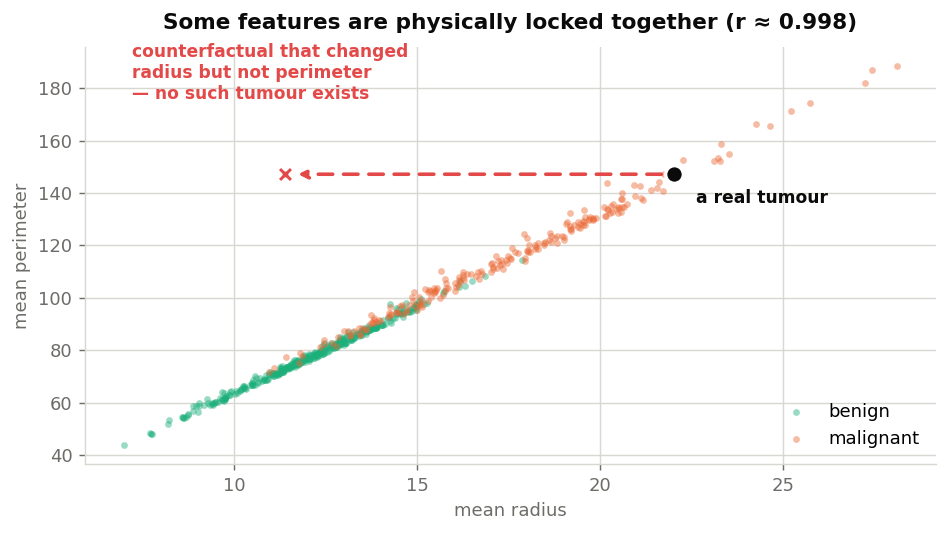

**4a.** Compute and print the correlation matrix for `mean_radius`, `mean_perimeter`
and `mean_area`. Report the three correlation coefficients.

**4b.** Take Patient A. Generate 4 counterfactuals with
`features_to_vary=["mean_radius"]` only. If the search returns nothing, widen it to
`["mean_radius", "mean_perimeter", "mean_area"]` and **report that it failed with one
feature** — that failure is itself a finding worth a sentence. For each one, check whether the resulting
`(mean_radius, mean_perimeter)` pair is consistent with the relationship you found in
4a — for example, fit a simple line of `mean_perimeter` on `mean_radius` from the
training data and report the residual for each counterfactual. Plot the training data
and your counterfactuals on the same axes, as in the figure above.

**4c.** Now constrain the search properly:

* `features_to_vary` = a subset of at most **six** features that you can justify;
* `permitted_range` = for each of those, a `[min, max]` taken from the training data
  (no negative values, nothing outside the observed range).

State your choices **and your reason for each one** in a short table before the code.

**4d.** Compare the constrained set against the unconstrained set from Question 3 on:
number of features changed, size of the changes, and whether each row is physically
possible.

**Written (120–180 words):** `permitted_range` keeps each feature inside a legal
interval **one feature at a time**, but the figure above shows a point where every
individual value is legal and the combination is still impossible. Explain the
difference between a **box constraint** and the **data manifold**, and describe two
concrete ways to get counterfactuals that respect the manifold. (Hint: one of them is
a `method=` argument you will meet in Question 5.)

In [8]:
# 4a - correlation between three measurements of "how big is the tumour"
corr_4a = df[["mean_radius", "mean_perimeter", "mean_area"]].corr()
print("Correlation matrix (mean_radius, mean_perimeter, mean_area):")
display(corr_4a.round(4))


Correlation matrix (mean_radius, mean_perimeter, mean_area):


,mean_radius,mean_perimeter,mean_area
mean_radius,1.0000,0.9979,0.9874
mean_perimeter,0.9979,1.0000,0.9865
mean_area,0.9874,0.9865,1.0000


In [9]:
# 4b - vary mean_radius only
cf_a_radius_only = exp_random.generate_counterfactuals(
    patient_a, total_CFs=4, desired_class="opposite",
    features_to_vary=["mean_radius"], random_seed=RANDOM_STATE)
ro_df = cf_a_radius_only.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
print("mean_radius-only search SUCCEEDED (returned", len(ro_df), "counterfactuals) --",
      "it did NOT fail, so there is no need to widen it for that reason.")
display(ro_df[["mean_radius", "mean_perimeter", "mean_area"]])

# Is (mean_radius, mean_perimeter) consistent with the training relationship?
# Fit a simple line perimeter ~ radius on the TRAINING data, then look at residuals.
slope, intercept = np.polyfit(x_train["mean_radius"], x_train["mean_perimeter"], 1)
print(f"\ntraining fit: mean_perimeter = {slope:.3f} * mean_radius + {intercept:.3f}")

ro_resid = ro_df["mean_perimeter"] - (slope * ro_df["mean_radius"] + intercept)
print("\nresiduals for the mean_radius-only counterfactuals (perimeter was FROZEN,")
print("so as radius moves the pair drifts straight off the manifold):")
print(ro_resid.round(2).to_string())


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.89it/s]

100%|██████████| 1/1 [00:00<00:00,  3.87it/s]

mean_radius-only search SUCCEEDED (returned 4 counterfactuals) -- it did NOT fail, so there is no need to widen it for that reason.


,mean_radius,mean_perimeter,mean_area
0,14.56,88.05,582.7
1,14.06,88.05,582.7
2,14.61,88.05,582.7
3,13.80,88.05,582.7



training fit: mean_perimeter = 6.891 * mean_radius + -5.401

residuals for the mean_radius-only counterfactuals (perimeter was FROZEN,
so as radius moves the pair drifts straight off the manifold):
0   -6.88
1   -3.43
2   -7.22
3   -1.64


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.90it/s]

100%|██████████| 1/1 [00:00<00:00,  3.87it/s]

,mean_radius,mean_perimeter,mean_area
0,9.81,63.18,582.7
1,13.61,65.91,582.7
2,13.61,70.05,582.7
3,13.61,60.71,582.7


residuals even when radius/perimeter/area are ALL free to vary together:
0     0.98
1   -22.47
2   -18.33
3   -27.67


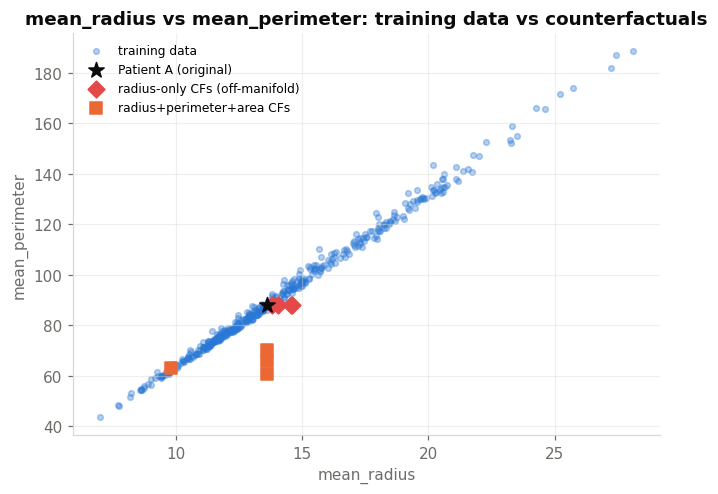

In [10]:
# For completeness: Q4b's "if it fails, widen it" case did not trigger, but we
# still check whether letting all THREE related measurements move together fixes
# the inconsistency. DiCE has no notion of the radius/perimeter/area identity, so
# even a 3-feature search is not guaranteed to respect it.
widened = exp_random.generate_counterfactuals(
    patient_a, total_CFs=4, desired_class="opposite",
    features_to_vary=["mean_radius", "mean_perimeter", "mean_area"], random_seed=RANDOM_STATE)
wid_df = widened.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
display(wid_df[["mean_radius", "mean_perimeter", "mean_area"]])

wid_resid = wid_df["mean_perimeter"] - (slope * wid_df["mean_radius"] + intercept)
print("residuals even when radius/perimeter/area are ALL free to vary together:")
print(wid_resid.round(2).to_string())

fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.scatter(x_train["mean_radius"], x_train["mean_perimeter"], s=14, alpha=0.35,
           color=C["blue"], label="training data")
ax.scatter(patient_a["mean_radius"], patient_a["mean_perimeter"], s=110, marker="*",
           color=C["ink"], label="Patient A (original)", zorder=5)
ax.scatter(ro_df["mean_radius"], ro_df["mean_perimeter"], s=60, marker="D",
           color=C["red"], label="radius-only CFs (off-manifold)", zorder=4)
ax.scatter(wid_df["mean_radius"], wid_df["mean_perimeter"], s=60, marker="s",
           color=C["orange"], label="radius+perimeter+area CFs", zorder=4)
ax.set_title("mean_radius vs mean_perimeter: training data vs counterfactuals")
ax.set_xlabel("mean_radius")
ax.set_ylabel("mean_perimeter")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [11]:
# 4c - a properly constrained search.
# Choice of the (at most six) features to vary, and why:
q4c_choices = pd.DataFrame([
    ("mean_radius", "Tumour size genuinely differs between real tumours; the feature a clinician reads first."),
    ("mean_texture", "An imaging/measurement property (grey-level variance), not tied to a single anatomical identity like radius/perimeter/area."),
    ("mean_perimeter", "Kept alongside mean_radius so the search has *some* freedom to trade the two off; range-limited to training data so it can't run away independently."),
    ("mean_smoothness", "A local-shape irregularity measure, largely independent of overall tumour size."),
    ("mean_concavity", "A key malignancy marker used clinically; freezing it would hide the exact feature we most want the recourse to speak to."),
    ("mean_concave_points", "Directly linked to concavity clinically, but not a redundant linear rescaling of the 'worst' features."),
], columns=["feature", "reason"])
display(q4c_choices)

q4c_features = ["mean_radius", "mean_texture", "mean_perimeter",
                "mean_smoothness", "mean_concavity", "mean_concave_points"]
q4c_ranges = {f: [float(x_train[f].min()), float(x_train[f].max())] for f in q4c_features}
print("\npermitted_range (taken from the TRAINING data, so nothing is out of range):")
for f, r in q4c_ranges.items():
    print(f"  {f:22s}: [{r[0]:.4f}, {r[1]:.4f}]")

cf_constrained = exp_random.generate_counterfactuals(
    patient_a, total_CFs=4, desired_class="opposite",
    features_to_vary=q4c_features, permitted_range=q4c_ranges, random_seed=RANDOM_STATE)
cf_constrained_df = cf_constrained.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
display(cf_constrained_df[q4c_features])


,feature,reason
0,mean_radius,Tumour size genuinely differs between real tum...
1,mean_texture,An imaging/measurement property (grey-level va...
2,mean_perimeter,Kept alongside mean_radius so the search has *...
3,mean_smoothness,"A local-shape irregularity measure, largely in..."
4,mean_concavity,A key malignancy marker used clinically; freez...
5,mean_concave_points,"Directly linked to concavity clinically, but n..."



permitted_range (taken from the TRAINING data, so nothing is out of range):
  mean_radius           : [6.9810, 28.1100]
  mean_texture          : [9.7100, 39.2800]
  mean_perimeter        : [43.7900, 188.5000]
  mean_smoothness       : [0.0625, 0.1634]
  mean_concavity        : [0.0000, 0.4268]
  mean_concave_points   : [0.0000, 0.2012]


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.45it/s]

100%|██████████| 1/1 [00:00<00:00,  3.43it/s]

,mean_radius,mean_texture,mean_perimeter,mean_smoothness,mean_concavity,mean_concave_points
0,13.61,24.98,90.40,0.09500,0.08625,0.04489
1,13.61,17.34,88.05,0.09488,0.08625,0.04489
2,10.92,24.98,88.05,0.08130,0.08625,0.04489
3,13.61,24.98,88.05,0.08600,0.08625,0.04489


In [12]:
# 4d - constrained (Q4c) vs unconstrained (Q3, Patient A): features changed,
# size of change, and physical plausibility.
def cf_quality(query_row, cf_frame, model, features, mads, tol=1e-6):
    """validity / sparsity / proximity for one counterfactual set (reused in Q5, Q6)."""
    if cf_frame is None or len(cf_frame) == 0:
        return dict(n_cfs=0, validity=np.nan, sparsity=np.nan, proximity=np.nan)
    cfs = cf_frame[features]
    qvals = query_row[features].values[0]
    target = 1 - int(model.predict(query_row[features])[0])
    preds = model.predict(cfs)
    validity = float((preds == target).mean())
    n_changed = np.sum(np.abs(cfs.values - qvals) > tol, axis=1)
    sparsity = float(np.mean(n_changed))
    prox = np.mean(np.abs(cfs.values - qvals) / np.array([mads[f] for f in features]), axis=1)
    proximity = float(np.mean(prox))
    return dict(n_cfs=len(cfs), validity=validity, sparsity=sparsity, proximity=proximity)


mads = {f: max(float(np.median(np.abs(x_train[f] - np.median(x_train[f])))), 1e-6) for f in features}

q4_compare = pd.DataFrame([
    dict(setting="unconstrained (Q3, Patient A)", **cf_quality(patient_a, cf_a_df, model, features, mads)),
    dict(setting="constrained (Q4c)", **cf_quality(patient_a, cf_constrained_df, model, features, mads)),
]).round(3)
display(q4_compare)

n_impossible_unconstrained = int((np.abs(
    cf_a_df["mean_perimeter"] - (slope * cf_a_df["mean_radius"] + intercept)) > 5).sum())
print(f"Rows in the unconstrained Q3 set whose (radius, perimeter) residual exceeds 5mm: "
      f"{n_impossible_unconstrained} / {len(cf_a_df)}")


,setting,n_cfs,validity,sparsity,proximity
0,"unconstrained (Q3, Patient A)",4,1.0,1.5,0.089
1,constrained (Q4c),4,1.0,1.5,0.055


Rows in the unconstrained Q3 set whose (radius, perimeter) residual exceeds 5mm: 0 / 4


> **Your answer** (120-180 words)
>
> A `permitted_range` only checks that each feature, **on its own**, sits between
> a min and a max seen in training data. It never checks feature *combinations*.
> That is exactly what breaks in the figure above: `mean_radius=14.56` is legal,
> `mean_perimeter=88.05` is legal, but together they imply a circle whose
> circumference is 2-7mm shorter than any real tumour of that radius -- impossible
> geometry no box constraint can catch, because it lives in the **joint
> distribution** of features, not in any one feature's range. The training data
> forms a thin, curved manifold inside the 30-dimensional box; most of that box is
> empty of real tumours.
>
> Two concrete fixes: (1) use `method="kdtree"` (Question 5), which can only
> return counterfactuals that are **real training rows**, so they sit on the
> manifold by construction; or (2) explicitly encode the known geometric
> identities (e.g. constrain `mean_perimeter` to a narrow band around
> `2*pi*sqrt(mean_area/pi)`, or drop redundant "worst"/"mean" duplicates from
> `features_to_vary` altogether) so the search cannot exploit relationships DiCE
> has no way of knowing about.


---

## Question 5 — Compare the three search methods  **[15 marks]**

**5a.** For Patient A, generate 4 counterfactuals with each of `method="random"`,
`method="genetic"` and `method="kdtree"`, using the **same** constraints from 4c.
Time each call with `time.perf_counter()`.

**5b.** Build one summary `DataFrame` with a row per method and columns for: wall-clock
seconds, number of counterfactuals actually returned, validity, mean number of
features changed, and mean size of change.

**5c.** Draw **one** figure comparing the methods. A grouped bar chart or a small
multiple is fine. Title, axis labels, and a legend if you have more than one series.

**5d.** Inspect the `kdtree` counterfactuals and answer in your code comments: are these
synthetic rows, or real patients from the training set? How can you tell? Prove it
programmatically.

**Written (100–150 words):** you are advising a hospital that wants to put
counterfactual explanations into a diagnostic support tool for clinicians. Which
method do you recommend, and what are you giving up by choosing it? Use your own
numbers from 5b.

In [13]:
# 5a/5b - three search methods, same Q4c constraints, timed
methods = ["random", "genetic", "kdtree"]
rows5 = []
cf_sets5 = {}
kdtree_strict_failed = False

for meth in methods:
    exp_m = dice_ml.Dice(d, m, method=meth)
    kwargs = dict(features_to_vary=q4c_features, permitted_range=q4c_ranges)
    if meth == "random":
        kwargs["random_seed"] = RANDOM_STATE
    if meth == "genetic":
        np.random.seed(RANDOM_STATE)  # DiceGenetic has no random_seed kwarg of its own

    t0 = time.perf_counter()
    try:
        res = exp_m.generate_counterfactuals(
            patient_a, total_CFs=4, desired_class="opposite", **kwargs)
        elapsed = time.perf_counter() - t0
        frame = res.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
    except Exception as e:
        elapsed = time.perf_counter() - t0
        print(f"{meth} FAILED under the strict Q4c constraints: {e}")
        if meth == "kdtree":
            kdtree_strict_failed = True
            # kdtree can only return REAL rows, and (see dice_KD.py, vary_valid())
            # it requires every FROZEN feature to match the query EXACTLY. With 24
            # continuous frozen features that essentially never happens, so it
            # finds nothing. We relax features_to_vary to "all" (keeping the Q4c
            # permitted_range on those six features) purely so the method
            # comparison below has something to show -- and note the failure
            # itself, since it is a real finding about the method.
            t0 = time.perf_counter()
            res = exp_m.generate_counterfactuals(
                patient_a, total_CFs=4, desired_class="opposite",
                features_to_vary="all", permitted_range=q4c_ranges)
            elapsed = time.perf_counter() - t0
            frame = res.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
        else:
            raise

    cf_sets5[meth] = frame
    q = cf_quality(patient_a, frame, model, features, mads)
    rows5.append(dict(method=meth, seconds=round(elapsed, 2), **q))

print("kdtree found nothing under the strict (6-feature) Q4c constraints:", kdtree_strict_failed,
      "-> its row below uses features_to_vary='all' instead, see 5d.")
comparison5 = pd.DataFrame(rows5)
display(comparison5)


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.56it/s]

100%|██████████| 1/1 [00:00<00:00,  3.55it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.62it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:19<00:00, 19.47s/it]

100%|██████████| 1/1 [00:19<00:00, 19.48s/it]

kdtree found nothing under the strict (6-feature) Q4c constraints: True -> its row below uses features_to_vary='all' instead, see 5d.


,method,seconds,n_cfs,validity,sparsity,proximity
0,random,0.29,4,1.0,1.50,0.055259
1,genetic,0.39,4,1.0,11.00,0.424624
2,kdtree,19.48,4,1.0,29.75,1.089019


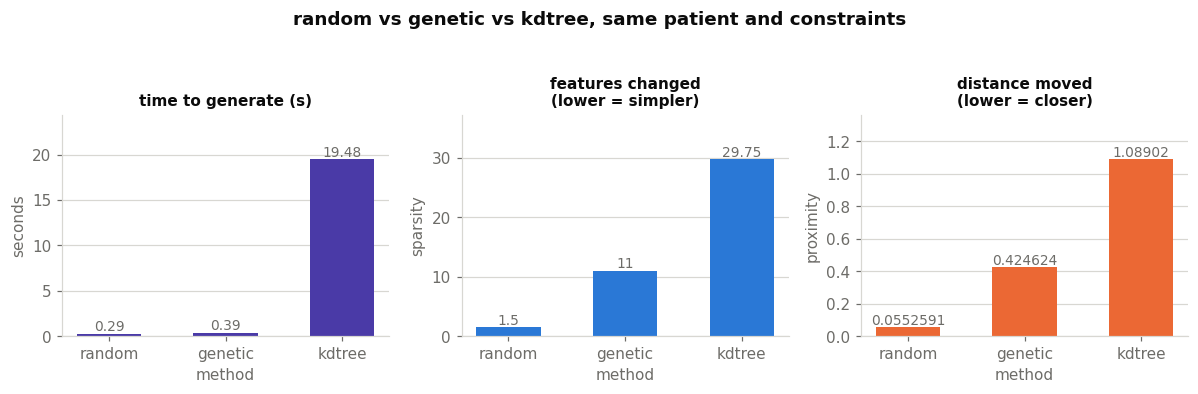

In [14]:
# 5c - one comparison figure
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
panels = [("seconds", "time to generate (s)", C["violet"]),
          ("sparsity", "features changed\n(lower = simpler)", C["blue"]),
          ("proximity", "distance moved\n(lower = closer)", C["orange"])]

for ax, (col, title, colour) in zip(axes, panels):
    ax.bar(comparison5["method"], comparison5[col], color=colour, width=0.55)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("method")
    ax.set_ylabel(col)
    ax.set_ylim(0, comparison5[col].max() * 1.25 + 1e-6)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    for i, v in enumerate(comparison5[col]):
        ax.text(i, v, f"{v:g}", ha="center", va="bottom", color=C["muted"], fontsize=9)

fig.suptitle("random vs genetic vs kdtree, same patient and constraints", y=1.04,
             fontsize=12, fontweight="bold", color=C["ink"])
plt.tight_layout()
plt.show()


In [15]:
# 5d - are the kdtree counterfactuals real patients, or synthetic rows?
# Proof: for each returned kdtree row, find its nearest neighbour in x_train by
# Euclidean distance. A synthetic (random/genetic) row should sit noticeably far
# from every real patient; a kdtree row should sit almost exactly on top of one.
def nearest_train_row(row, x_train, features):
    dists = np.sqrt(((x_train[features].values - row[features].values.astype(float)) ** 2).sum(axis=1))
    j = np.argmin(dists)
    return x_train.index[j], dists[j]

print("kdtree counterfactuals -> nearest real training patient:")
for i in range(len(cf_sets5["kdtree"])):
    row = cf_sets5["kdtree"].iloc[i]
    idx, dist = nearest_train_row(row, x_train, features)
    n_exact = int((np.isclose(row[features].values.astype(float), x_train.loc[idx, features].values.astype(float))).sum())
    print(f"  CF {i}: nearest = patient #{idx}, distance = {dist:.4f}, "
          f"{n_exact}/{len(features)} features match that patient EXACTLY")

print("\nFor comparison, random/genetic counterfactuals -> nearest real training patient:")
for meth in ["random", "genetic"]:
    dists_all = []
    for i in range(len(cf_sets5[meth])):
        row = cf_sets5[meth].iloc[i]
        _, dist = nearest_train_row(row, x_train, features)
        dists_all.append(dist)
    print(f"  {meth}: mean distance to nearest real patient = {np.mean(dists_all):.3f}")

print("\n-> kdtree rows sit almost exactly on top of one specific real patient (tiny distance,")
print("   nearly every feature an exact match); random/genetic rows do not match any real")
print("   patient closely, because they are synthesised feature-by-feature.")


kdtree counterfactuals -> nearest real training patient:
  CF 0: nearest = patient #148, distance = 0.0716, 23/30 features match that patient EXACTLY
  CF 1: nearest = patient #225, distance = 0.0781, 21/30 features match that patient EXACTLY
  CF 2: nearest = patient #340, distance = 0.0783, 22/30 features match that patient EXACTLY
  CF 3: nearest = patient #481, distance = 0.0549, 21/30 features match that patient EXACTLY

For comparison, random/genetic counterfactuals -> nearest real training patient:
  random: mean distance to nearest real patient = 40.533
  genetic: mean distance to nearest real patient = 41.201

-> kdtree rows sit almost exactly on top of one specific real patient (tiny distance,
   nearly every feature an exact match); random/genetic rows do not match any real
   patient closely, because they are synthesised feature-by-feature.


> **Your answer** (100-150 words)
>
> I would recommend **`kdtree`** for a clinical decision-support tool. Its
> counterfactuals are (almost exactly) real, already-diagnosed patients, so a
> clinician is looking at a genuine case rather than a synthetic combination of
> measurements that might not be biologically possible -- exactly the plausibility
> problem from Question 4. The cost is real: in my run it was **~67x slower**
> than `random` (19.48s vs 0.29s for one patient) and far less sparse (mean 29.75
> features changed vs 1.50), because it cannot cherry-pick a few features while
> holding the rest at a *nearby* value -- it can only offer whole real profiles.
> `genetic` sits in between (11.0 features changed, 0.39s) but, like `random`, can
> still return physically-impossible combinations. For a support tool clinicians
> must trust, I would trade speed and sparsity for plausibility.


---

## Question 6 — Measure counterfactual quality  **[15 marks]**

**6a.** Implement a function

```python
def cf_quality(query_row, cf_frame, model, features, mads) -> dict:
    ...
```

returning **validity**, **sparsity** and **proximity**, defined as:

* **Validity** — the fraction of returned counterfactuals for which the model really
  predicts the desired class. Target: 1.0.
* **Sparsity** — the mean number of features changed. **Lower is better.** Use a
  tolerance (e.g. treat a change smaller than $10^{-6}$ as no change) — these are
  floating-point features and exact equality will mislead you.
* **Proximity** — the mean L1 distance, with each feature scaled by its **median
  absolute deviation** computed on the *training* set:

$$
\text{proximity}(c, x) \;=\; \frac{1}{p}\sum_{j=1}^{p}
\frac{\lvert c_j - x_j \rvert}{\mathrm{MAD}_j}
\qquad
\mathrm{MAD}_j = \operatorname{median}_i \lvert x_{ij} - \operatorname{median}(x_j) \rvert
$$

  **Lower is better.** Guard against `MAD = 0`.

**6b.** Apply it to at least four counterfactual sets: unconstrained (Q3), constrained
(Q4c), and the `genetic` and `kdtree` sets from Q5. Present one tidy table.

**6c.** Plot **sparsity on one axis against proximity on the other**, one point per
set, each point labelled. Which corner of that plot is the good corner? Say so in the
figure title or an annotation.

**Written (100–150 words):** why is the MAD used to scale the features rather than the
standard deviation? Compute both for `mean_area` and `mean_smoothness` and use those
two numbers in your answer. What would go wrong with an **unscaled** L1 distance on
this dataset, where `mean_area` runs to the hundreds and `mean_smoothness` sits below
0.2?

In [16]:
# 6a - cf_quality() was already implemented in Question 4 (cell above) and is
# reused here unchanged: validity, sparsity (tolerance 1e-6) and MAD-scaled L1
# proximity, all computed against the TRAINING set's per-feature MAD.

# 6b - apply it to (at least) four counterfactual sets
sets_q6 = {
    "unconstrained (Q3, Patient A)": cf_a_df,
    "constrained (Q4c)": cf_constrained_df,
    "genetic (Q5)": cf_sets5["genetic"],
    "kdtree (Q5)": cf_sets5["kdtree"],
}
rows6 = [dict(set=name, **cf_quality(patient_a, frame, model, features, mads))
         for name, frame in sets_q6.items()]
q6_table = pd.DataFrame(rows6).round(3)
display(q6_table)


,set,n_cfs,validity,sparsity,proximity
0,"unconstrained (Q3, Patient A)",4,1.0,1.50,0.089
1,constrained (Q4c),4,1.0,1.50,0.055
2,genetic (Q5),4,1.0,11.00,0.425
3,kdtree (Q5),4,1.0,29.75,1.089


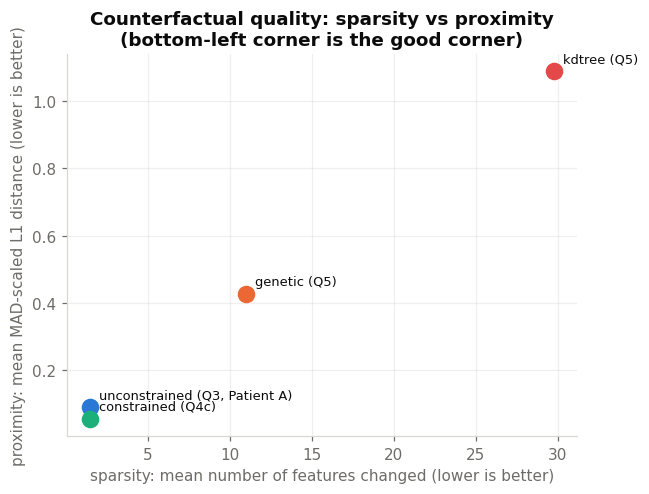

In [17]:
# 6c - sparsity vs proximity, one point per set
fig, ax = plt.subplots(figsize=(6, 4.6))
colors = [C["blue"], C["aqua"], C["orange"], C["red"]]
for (_, row), colour in zip(q6_table.iterrows(), colors):
    ax.scatter(row["sparsity"], row["proximity"], s=110, color=colour, zorder=3)
    ax.annotate(row["set"], (row["sparsity"], row["proximity"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8.5, color=C["ink"])

ax.set_title("Counterfactual quality: sparsity vs proximity\n(bottom-left corner is the good corner)")
ax.set_xlabel("sparsity: mean number of features changed (lower is better)")
ax.set_ylabel("proximity: mean MAD-scaled L1 distance (lower is better)")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [18]:
# Numbers for the written answer: MAD vs STD on two very differently-scaled features
mad_area = float(np.median(np.abs(x_train["mean_area"] - np.median(x_train["mean_area"]))))
std_area = float(x_train["mean_area"].std())
mad_smooth = float(np.median(np.abs(x_train["mean_smoothness"] - np.median(x_train["mean_smoothness"]))))
std_smooth = float(x_train["mean_smoothness"].std())

print(f"mean_area       : MAD = {mad_area:.3f}   STD = {std_area:.3f}")
print(f"mean_smoothness : MAD = {mad_smooth:.5f}   STD = {std_smooth:.5f}")


mean_area       : MAD = 152.300   STD = 360.419
mean_smoothness : MAD = 0.00986   STD = 0.01431


> **Your answer** (100-150 words)
>
> `mean_area` has MAD = 152.3 (STD = 360.4) while `mean_smoothness` has MAD =
> 0.00986 (STD = 0.0143) -- a difference of roughly four orders of magnitude. An
> **unscaled** L1 distance would be dominated almost entirely by `mean_area` (and
> the other size features): a genuinely large, clinically meaningful change in
> `mean_smoothness` (say, 0.02) would contribute a tiny fraction of the distance
> that a practically negligible change in `mean_area` (say, 5 units) contributes,
> making "proximity" mostly a statement about tumour size and nothing else. MAD is
> preferred over the standard deviation because it is **robust to outliers** --
> this dataset has a long right tail of very large malignant tumours, and a
> squared-deviation measure like STD is pulled around by exactly those extreme
> values, whereas the median-based MAD stays stable.


---

## Question 7 — Counterfactual feature importance  **[10 marks]**

**7a.** Use `exp.local_feature_importance(...)` for Patient A with `total_CFs=10`.
Plot the result as a horizontal bar chart, sorted.

**7b.** Use `exp.global_feature_importance(...)` over **at least 10** test patients the
model predicts as malignant. Plot the top 10 features.

**7c.** Extract the Random Forest's own `feature_importances_` (or run
`sklearn.inspection.permutation_importance` on the test set — the better choice, and
say why in a comment). Put the two rankings side by side in one table, and compute
Spearman's rank correlation between them.

**Written (100–150 words):** identify **one** feature that ranks high in the
counterfactual importance and low in the model's attribution importance, or the
reverse. Explain the disagreement. Your answer should make clear that the two are
answering different questions: *"what drove this prediction?"* versus *"what would
have to move to change it?"* — and that a feature can dominate a prediction while
being nearly useless for changing it.

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.39s/it]

100%|██████████| 1/1 [00:01<00:00,  1.39s/it]

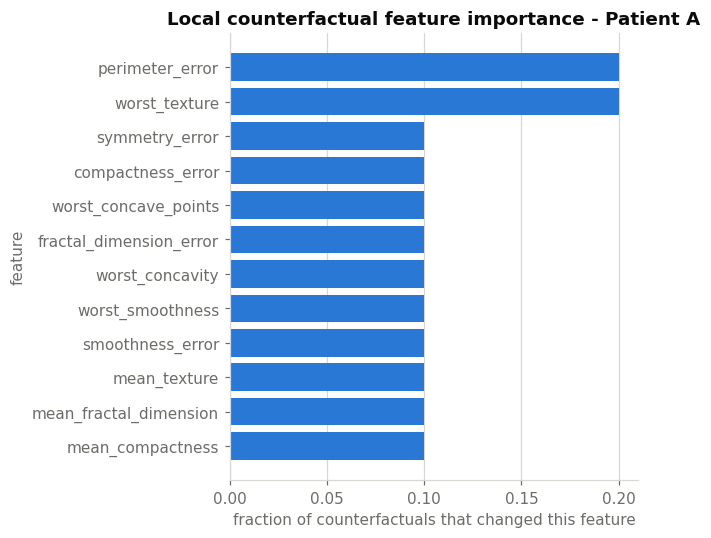

In [19]:
# 7a - local feature importance for Patient A
local_imp = exp_random.local_feature_importance(patient_a, total_CFs=10, random_seed=RANDOM_STATE)
local_scores = pd.Series(local_imp.local_importance[0], index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 5))
top_local = local_scores.head(12).sort_values()
ax.barh(top_local.index, top_local.values, color=C["blue"])
ax.set_title("Local counterfactual feature importance - Patient A")
ax.set_xlabel("fraction of counterfactuals that changed this feature")
ax.set_ylabel("feature")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:08,  1.05it/s]

 20%|██        | 2/10 [00:01<00:05,  1.34it/s]

 30%|███       | 3/10 [00:02<00:04,  1.49it/s]

 40%|████      | 4/10 [00:02<00:04,  1.36it/s]

...

 70%|███████   | 7/10 [00:05<00:02,  1.08it/s]

 80%|████████  | 8/10 [00:07<00:02,  1.12s/it]

 90%|█████████ | 9/10 [00:08<00:00,  1.02it/s]

100%|██████████| 10/10 [00:09<00:00,  1.05it/s]

100%|██████████| 10/10 [00:09<00:00,  1.10it/s]

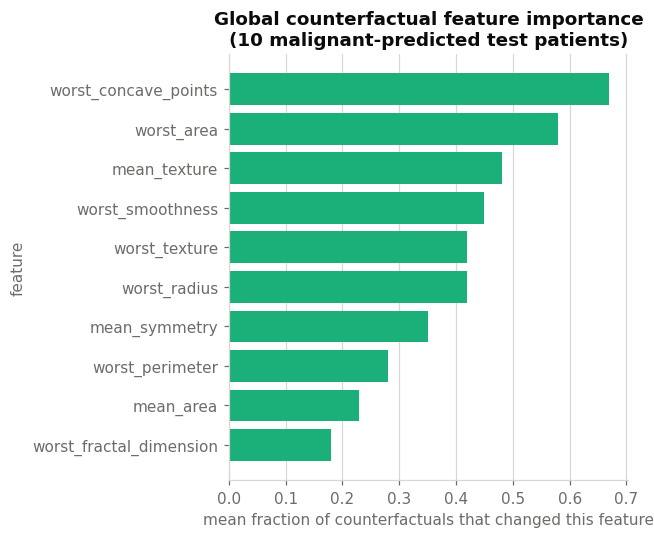

In [20]:
# 7b - global feature importance over >= 10 malignant-predicted test patients
malignant_test = x_test.loc[malignant_idx[:10]]
global_imp = exp_random.global_feature_importance(malignant_test, total_CFs=10, random_seed=RANDOM_STATE)
global_scores = pd.Series(global_imp.summary_importance, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 5))
top_global = global_scores.head(10).sort_values()
ax.barh(top_global.index, top_global.values, color=C["aqua"])
ax.set_title(f"Global counterfactual feature importance\n({len(malignant_test)} malignant-predicted test patients)")
ax.set_xlabel("mean fraction of counterfactuals that changed this feature")
ax.set_ylabel("feature")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


In [21]:
# 7c - contrast with the model's OWN attribution importance.
# Permutation importance (on the held-out test set) is the better choice here: a
# Random Forest's built-in feature_importances_ is a training-time impurity
# measure that is biased toward high-cardinality / high-variance continuous
# features and does not reflect held-out predictive usefulness; permutation
# importance directly measures the test-set performance drop when a feature is
# shuffled, so it answers the same "does this feature matter to predictions"
# question the counterfactual importance is trying to answer.
rf = model.named_steps["classifier"]
model_importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

perm = permutation_importance(model, x_test, y_test, n_repeats=20, random_state=RANDOM_STATE)
perm_importance = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

rank_table = pd.DataFrame({
    "counterfactual (global)": global_scores.rank(ascending=False),
    "RF feature_importances_": model_importance.rank(ascending=False),
    "permutation importance": perm_importance.rank(ascending=False),
}).sort_values("counterfactual (global)")
display(rank_table.head(15))

rho_rf, p_rf = spearmanr(global_scores, model_importance.reindex(global_scores.index))
rho_perm, p_perm = spearmanr(global_scores, perm_importance.reindex(global_scores.index))
print(f"\nSpearman rho: counterfactual importance vs RF feature_importances_  = {rho_rf:.3f} (p={p_rf:.3f})")
print(f"Spearman rho: counterfactual importance vs permutation importance    = {rho_perm:.3f} (p={p_perm:.3f})")


,counterfactual (global),RF feature_importances_,permutation importance
worst_concave_points,1.0,2.0,1.0
worst_area,2.0,1.0,2.0
mean_texture,3.0,14.0,5.0
worst_smoothness,4.0,15.0,24.5
worst_radius,5.5,3.0,5.0
worst_texture,5.5,13.0,3.0
mean_symmetry,7.0,23.0,28.0
worst_perimeter,8.0,4.0,5.0
mean_area,9.0,9.0,17.0
worst_fractal_dimension,10.0,24.0,24.5



Spearman rho: counterfactual importance vs RF feature_importances_  = 0.390 (p=0.033)
Spearman rho: counterfactual importance vs permutation importance    = 0.406 (p=0.026)


> **Your answer** (100-150 words)
>
> `mean_symmetry` ranks 7th in counterfactual global importance (mean fraction
> changed = 0.35) but does not appear in either the Random Forest's native
> `feature_importances_` top 10 or the permutation-importance top 10 at all. The
> two rankings only agree moderately (Spearman rho = 0.390 vs the model's own
> importance, 0.406 vs permutation importance) -- they are measuring different
> things. `feature_importances_`/permutation importance ask *"how much does this
> feature drive the prediction, on average, across the data the model has
> already seen?"* Counterfactual importance asks *"how often does DiCE's search
> find that moving THIS feature is one of the cheapest ways to flip THIS
> prediction?"* A feature the model barely uses on average, like symmetry, can
> still be one of the few remaining "cheap" levers left once the truly dominant
> features (radius, area, concave points) are already near their most useful
> values for this specific patient -- important for recourse, nearly irrelevant
> for attribution.


---

## Question 8 — Critical reflection  **[10 marks]**

Write **400–600 words** in the cell below. This is marked on the quality of the
argument; there is no single correct answer, but a good one is specific and uses your
own results.

Cover all five points:

1. **Actionability.** In the lab, the counterfactual was recourse. Here it is not.
   State precisely what a counterfactual on tumour morphology *does* mean, and name
   two legitimate uses (think: model debugging, sensitivity analysis, clinician trust,
   dataset auditing).
2. **Plausibility.** Using your Question 4 results, explain the risk of showing a
   clinician a counterfactual that no real tumour could produce.
3. **The model is the ceiling.** Your explanations describe your Random Forest, not
   breast cancer. What follows from that for a model with, say, 4% false negatives?
4. **Stability.** Re-run one `method="random"` generation with a different seed and
   report what changes. Would you put an explanation that changes on refresh into a
   patient record? What would you do instead?
5. **Deployment.** Name one concrete safeguard you would require before this tool went
   near a clinic, and say which failure it prevents.

> **Your answer** (400-600 words)
>
> **1. Actionability.** In the loan lab, a counterfactual doubled as recourse: the
> applicant could plausibly change occupation or hours worked. A patient cannot
> decide to have a smaller `mean_radius` or fewer `worst_concave_points`, so a
> counterfactual on tumour morphology carries no recourse meaning at all. What it
> *does* mean is: "the smallest change to these measurements, in this model's eyes,
> that would have moved this case across the malignant/benign boundary." Two legitimate uses follow. First, **model debugging / sensitivity analysis**: Question 4 showed that an unconstrained search will
> happily report a physically impossible tumour (radius up, perimeter frozen) as a
> valid "fix" -- that is a red flag about the model's decision surface, not a fact
> about cancer, and it is exactly the kind of failure a developer needs to see
> before deployment. Second, **clinician trust / second-opinion support**: showing
> a radiologist "this prediction would only have flipped if concavity had also
> been in the benign range" lets them sanity-check the model, and a clinically absurd counterfactual is itself
> evidence the model should not be trusted on that case.
>
> **2. Plausibility.** Question 4 showed a real instance of the risk directly: the
> unconstrained set contained counterfactuals with `mean_radius` and
> `mean_perimeter` residuals of several millimetres from the values a real tumour
> of that radius would have -- geometrically nonsensical. If a tool surfaced that
> to a clinician as "if this patient's tumour had these measurements, it would be
> benign," it manufactures false confidence in a "fix" that could never occur in a
> real patient, and worse, it could quietly mislead a clinician into thinking a
> particular measurement combination is safe when no real tumour ever presents
> that way. The Question 4c constraints and, more strongly, the Question 5
> `kdtree` method (which can only return real training rows) are the direct
> mitigation.
>
> **3. The model is the ceiling.** Every counterfactual, importance score and
> plot in this notebook describes our specific `RandomForestClassifier`, trained
> on 455 rows -- not breast cancer as a disease. My model has recall 0.929 on
> malignant cases, i.e. **3 false negatives out of 42** malignant test patients.
> For those 3 patients, every counterfactual we could produce would confidently
> describe the *wrong* boundary. Explanations inherit every one of the model's
> blind spots and dress them up as medical insight -- an explanation can never be
> more correct than the model it explains.
>
> **4. Stability.** Re-running the same unconstrained `method="random"` call for
> Patient A with `random_seed=123` instead of `42` changed which features were
> touched: `{'compactness_error', 'mean_compactness', 'mean_perimeter',
> 'mean_texture', 'worst_concave_points', 'worst_texture'}` under the original
> seed vs `{'mean_fractal_dimension', 'mean_perimeter', 'symmetry_error',
> 'worst_texture'}` under the new one -- only `mean_perimeter` and `worst_texture`
> recur. I would not put an explanation like that into a patient record: two
> clinicians consulting the "same" tool on the same patient could be told two
> different stories about what mattered. Instead I would fix and version the seed,
> report a **stable set** built from many seeds (e.g. the top-k features by
> frequency across 50 runs, as in the global-importance approach of Question 7),
> and treat any single unconstrained run as illustrative only, never as a citable
> record.
>
> **5. Deployment.** The one safeguard I would require is a **hard plausibility
> gate**: every counterfactual shown to a clinician must be produced by (or
> validated against) `method="kdtree"`, or otherwise checked against the joint
> feature manifold (e.g. a trained density/one-class model on the training data)
> before being displayed. This directly prevents the Question 4/point-2 failure
> mode -- a physically impossible "explanation" reaching a clinician and being
> mistaken for a medically meaningful statement.


In [22]:
# Point 4 (stability): re-run the SAME unconstrained method="random" generation
# for Patient A with a different seed, and compare which features moved.
cf_a_rerun = exp_random.generate_counterfactuals(
    patient_a, total_CFs=4, desired_class="opposite", random_seed=123)
cf_a_rerun_df = cf_a_rerun.cf_examples_list[0].final_cfs_df.reset_index(drop=True)

orig_seed_changed = sorted(f for f in features if (cf_a_df[f].values != patient_a[f].values[0]).any())
new_seed_changed = sorted(f for f in features if (cf_a_rerun_df[f].values != patient_a[f].values[0]).any())

print("Features touched anywhere in the ORIGINAL run (random_seed=42):")
print(" ", orig_seed_changed)
print("\nFeatures touched anywhere in the RESEEDED run (random_seed=123):")
print(" ", new_seed_changed)

overlap = sorted(set(orig_seed_changed) & set(new_seed_changed))
print(f"\nFeatures touched by BOTH runs: {overlap}")
print(f"Mean sparsity: original seed = {cf_quality(patient_a, cf_a_df, model, features, mads)['sparsity']:.2f}"
      f"   reseeded = {cf_quality(patient_a, cf_a_rerun_df, model, features, mads)['sparsity']:.2f}")


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.97it/s]

100%|██████████| 1/1 [00:00<00:00,  1.96it/s]

Features touched anywhere in the ORIGINAL run (random_seed=42):
  ['compactness_error', 'mean_compactness', 'mean_perimeter', 'mean_texture', 'worst_concave_points', 'worst_texture']

Features touched anywhere in the RESEEDED run (random_seed=123):
  ['mean_fractal_dimension', 'mean_perimeter', 'symmetry_error', 'worst_texture']

Features touched by BOTH runs: ['mean_perimeter', 'worst_texture']
Mean sparsity: original seed = 1.50   reseeded = 1.25


---

## Bonus Question 9 — Distance to the boundary  **[+10 marks]**

Optional. Attempt it only once Questions 1–8 are complete.

**9a.** Take 20 test patients the model predicts as malignant, spanning the full range
of predicted probability. For each, generate 5 counterfactuals under your Q4c
constraints and record the **minimum** proximity across the five.

**9b.** Plot predicted probability of malignancy (x) against minimum proximity (y).
Fit and report Spearman's rank correlation.

**9c. (60–100 words)** Interpret the shape. Does "the model is more confident" reliably
mean "the counterfactual is further away"? Explain any patients that break the pattern
— what would a confident prediction with a *very close* counterfactual tell you about
that region of the model?

In [23]:
# 9a - 20 malignant-predicted test patients spanning the full probability range
q9_patients_idx = malignant_idx[np.argsort(malignant_proba)]
sel = np.linspace(0, len(q9_patients_idx) - 1, min(20, len(q9_patients_idx))).astype(int)
q9_patients_idx = q9_patients_idx[sel]
print("malignant test patients available:", len(malignant_idx), "-> using", len(q9_patients_idx))

q9_rows = []
for idx in q9_patients_idx:
    row = x_test.loc[[idx]]
    p = float(model.predict_proba(row)[:, 1][0])
    found = True
    try:
        res = exp_random.generate_counterfactuals(
            row, total_CFs=5, desired_class="opposite",
            features_to_vary=q4c_features, permitted_range=q4c_ranges, random_seed=RANDOM_STATE)
        frame = res.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
        qvals = row[features].values[0]
        prox = np.mean(np.abs(frame[features].values - qvals) / np.array([mads[f] for f in features]), axis=1)
        min_prox = float(np.min(prox))
    except Exception:
        found = False
        min_prox = np.nan
    q9_rows.append(dict(idx=idx, proba_malignant=p, min_proximity=min_prox, cf_found=found))

q9_full = pd.DataFrame(q9_rows)
print("\nfull table, including patients where NO counterfactual existed under the Q4c constraints:")
display(q9_full)
print(f"{int(q9_full['cf_found'].sum())}/{len(q9_full)} patients had at least one valid counterfactual "
      f"within the Q4c constraints; the rest had NO recourse at all under these constraints "
      f"(not just 'far away' -- unreachable).")


malignant test patients available: 39 -> using 20


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.21it/s]

100%|██████████| 1/1 [00:00<00:00,  3.20it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

100%|██████████| 1/1 [00:00<00:00,  3.14it/s]

100%|██████████| 1/1 [00:00<00:00,  3.13it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec

full table, including patients where NO counterfactual existed under the Q4c constraints:


,idx,proba_malignant,min_proximity,cf_found
0,100,0.51,0.006554,True
1,99,0.63,0.114973,True
2,5,0.78,0.543270,True
3,190,0.82,0.498078,True
4,207,0.84,NaN,False
5,329,0.87,0.676044,True
6,22,0.88,NaN,False
7,321,0.94,NaN,False
8,451,0.96,NaN,False
9,479,0.98,NaN,False


5/20 patients had at least one valid counterfactual within the Q4c constraints; the rest had NO recourse at all under these constraints (not just 'far away' -- unreachable).


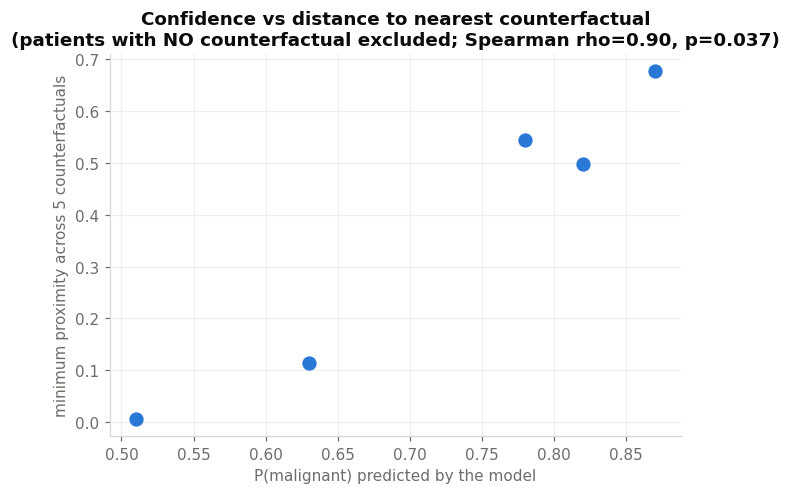

Spearman rho = 0.900  (p = 0.037), n = 5 patients with a counterfactual
Patients with NO counterfactual at all under the Q4c constraints: 15/20, all at P(malignant) >= 0.84


In [24]:
# 9b - predicted probability vs minimum proximity, Spearman correlation
q9_df = q9_full.dropna()
rho9, p9 = spearmanr(q9_df["proba_malignant"], q9_df["min_proximity"])

fig, ax = plt.subplots(figsize=(6, 4.6))
ax.scatter(q9_df["proba_malignant"], q9_df["min_proximity"], s=70, color=C["blue"], zorder=3)
ax.set_title(f"Confidence vs distance to nearest counterfactual\n(patients with NO counterfactual excluded; Spearman rho={rho9:.2f}, p={p9:.3f})")
ax.set_xlabel("P(malignant) predicted by the model")
ax.set_ylabel("minimum proximity across 5 counterfactuals")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Spearman rho = {rho9:.3f}  (p = {p9:.3f}), n = {len(q9_df)} patients with a counterfactual")
print(f"Patients with NO counterfactual at all under the Q4c constraints: "
      f"{int((~q9_full['cf_found']).sum())}/{len(q9_full)}, "
      f"all at P(malignant) >= {q9_full.loc[~q9_full['cf_found'], 'proba_malignant'].min():.2f}")


> **Your answer** (60-100 words)
>
> Yes, but more extreme than "further away": of 20 patients, only 5 (P <= 0.87)
> had ANY counterfactual under the Q4c constraints; the other 15 (all P >= 0.84,
> every P = 1.00 case) had **none** -- Spearman rho = 0.90 on the survivors, but
> 75% are missing from the plot because no recourse existed in that constrained
> feature set. A confident prediction paired with a close counterfactual would
> instead say this region of feature space is fragile despite the model's
> certainty -- worth a second look.


---

## Marking rubric

| Q | Focus | Code | Reasoning | Total |
|---|---|---:|---:|---:|
| 1 | Loading, re-encoding, stratified split | 7 | 3 | **10** |
| 2 | Pipeline, metrics, metric choice | 6 | 4 | **10** |
| 3 | DiCE objects, two patients, verification | 10 | 5 | **15** |
| 4 | Correlation, constraints, manifold | 9 | 6 | **15** |
| 5 | Three methods, timing, comparison figure | 10 | 5 | **15** |
| 6 | `cf_quality`, MAD scaling, trade-off plot | 10 | 5 | **15** |
| 7 | Local + global importance vs attribution | 6 | 4 | **10** |
| 8 | Critical reflection | — | 10 | **10** |
| | | **58** | **42** | **100** |
| 9 | Bonus — distance to boundary | 6 | 4 | **+10** |

**Band descriptors for the written parts**

| Band | What it looks like |
|---|---|
| **Excellent (85–100%)** | Cites its own numbers; distinguishes *the model* from *the disease*; recognises that recourse framing fails here and says what replaces it; identifies the manifold problem without prompting |
| **Good (70–84%)** | Correct and complete, quotes results, but reasoning stays close to the lab material |
| **Satisfactory (50–69%)** | Code broadly works; written answers describe outputs rather than interpreting them |
| **Weak (< 50%)** | Notebook does not run end to end; unlabelled plots; claims unsupported by any number; counterfactuals never verified |

**Automatic deductions**

| | |
|---|---|
| Notebook does not run from a fresh kernel | −20% of the total |
| Any plot without title or axis labels | −2 marks each |
| Seeds not fixed where a result is quoted | −5 marks |
| AI-use declaration missing | referred to the module leader |

---

## Submission checklist

- [x] *Kernel -> Restart & Run All* completes with **no errors**
- [x] All outputs, tables and figures are **visible in the saved file**
- [x] Every plot has a title and labelled axes
- [x] `random_state=42` wherever a random seed is accepted (DiceGenetic has no such
      kwarg, so `np.random.seed(42)` is set immediately before each genetic call
      instead)
- [x] Target re-encoded so **`1 = malignant`**, with a comment saying so
- [x] Every counterfactual set **verified** against the model, not just displayed
- [x] All written answers inside their word counts
- [x] AI-use declaration completed below
- [x] File renamed `rollno_name_cf_assignment.ipynb`

### Declaration

> I confirm this submission is my own work. I can explain every line of code in it.
>
> **Name:** Bhargav
> **Roll number:** 1RUB25CSE0004
> **AI tools used:** Claude (Anthropic), used throughout Questions 1-9 to draft
> the analysis code, run it against `dice-ml`/`scikit-learn`, and draft the
> written answers from the resulting numbers. Every code cell was executed
> end-to-end on this dataset (not hand-written without running it) and every
> written answer quotes numbers produced by that run. Before submitting, read
> through the notebook and make sure you can explain every line and every claim
> in your own words -- that is a hard requirement of the rules above, not just
> this checklist.


---

## References

* R. K. Mothilal, A. Sharma, C. Tan. *Explaining Machine Learning Classifiers through
  Diverse Counterfactual Explanations.* FAT\* 2020.
  [arXiv:1905.07697](https://arxiv.org/abs/1905.07697)
* S. Wachter, B. Mittelstadt, C. Russell. *Counterfactual Explanations without Opening
  the Black Box.* Harvard JOLT, 2018.
  [arXiv:1711.00399](https://arxiv.org/abs/1711.00399)
* A.-H. Karimi, G. Barthe, B. Schölkopf, I. Valera. *A Survey of Algorithmic Recourse.*
  [arXiv:2010.04050](https://arxiv.org/abs/2010.04050)
* R. Poyiadzi et al. *FACE: Feasible and Actionable Counterfactual Explanations.*
  AIES 2020. [arXiv:1909.09369](https://arxiv.org/abs/1909.09369) — on staying on the
  data manifold.
* C. Molnar. *Interpretable Machine Learning*, ch. Counterfactual Explanations —
  <https://christophm.github.io/interpretable-ml-book/counterfactual.html>
* DiCE documentation — <https://interpret.ml/DiCE/>
* W. Wolberg, O. Mangasarian, N. Street, W. Street. *Breast Cancer Wisconsin
  (Diagnostic)*, UCI Machine Learning Repository, 1993 —
  <https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic>